# PTI-Clima Notebooks  <img src="https://www.r-project.org/logo/Rlogo.png" alt="Description" width="60" height="40">

***

> Este cuaderno (notebook) presenta una serie de operaciones sencillas para cargar y visualizar un conjunto de datos de la PTI-Clima disponible en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Guía para el uso del dataset: ERA5-Land

**M. Fuente-González** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

**¡Bienvenidos al cuaderno “Guía para el uso del dataset: ERA5-Land” de la Plataforma Virtual de Cálculo de la PTI-Clima!**

En este notebook verás cómo cargar y examinar el dataset ERA5-Land disponible en el Almacén de Datos de la PTI-Clima. Este notebook tiene como objetivo principal facilitar su reutilización y asegurar la reproducibilidad de productos climáticos. La guía recorre los pasos esenciales para acceder a los datos, definir peticiones de carga y visualizar los resultados.

La Plataforma Virtual de Cálculo ofrece, además, un **notebook de primeros pasos** y una **colección de notebooks temáticos** (p. ej., intercomparación de conjuntos de datos observacionales o cálculo de índices) que puedes consultar para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.

Todo el flujo de trabajo se realiza con ***climate4R***, un framework de librerías en R para la carga, el postprocesado y el análisis de datos climáticos.

<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

### Contenido de este cuaderno
1) Carga de librerías
2) Selección de conjuntos de datos  
3) Carga de datos y visualización

Antes de empezar, o en cualquier momento durante el cuaderno, podemos personalizar el área de visualización de gráficos de la siguiente manera:

In [1]:
library(repr)
# Change plot size 
options(repr.plot.width=8, repr.plot.height=5)

Empezamos asignando a la JVM (Máquina Virtual de Java) la memoria que estimemos necesaria para la carga de datos que realizaremos.

In [2]:
options(java.parameters = "-Xmx10g")

### 1. Carga de librerías

Para las operaciones que se llevan a cabo en este notebook solo necesitaremos tres librerías de ***climate4R***: `loadeR` para la carga de datos, `transformeR` para calcular agregaciones temporales y extraer subconjuntos de información, y `visualizeR para` la representación gráfica de los resultados.

In [3]:
library(loadeR)
library(transformeR)
library(visualizeR)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



### 2. Selección de conjuntos de datos  

El inventario `data_inventory.csv` cataloga la lista de archivos del Almacén de datos de la PTI-Clima.

Basta con leer este archivo mediante `read.csv` para obtener el `data.frame` que contiene esta información.

In [4]:
df <- read.csv("../../data_inventory.csv")

A continuación mostramos el cabecero del inventario.

In [5]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-ROCIO-IBEB-regular_Iberia_day,observations,opendap,AEMET-ROCIO-IBEB-regular,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-5KM-regular/Iberia/day/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-IBEB-regular.dic
2,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
3,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Canarias/day/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


Para encontrar fácilmente el dataset que nos interesa usaremos la función `subset`. Especificando `source == "ERA5-Land"` obtenemos la lista de dos datasets, uno para la Península Ibérica (*Iberia*) y otro para las Islas Canarias (*Canarias*). 

In [6]:
subset(df, source == "ERA5-Land") 

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
121,ERA5-Land_Canarias_day,reanalysis,opendap,ERA5-Land,ecmwf,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/REANALYSIS/ERA5-Land/Canarias/day/ERA5-Land_Canarias_day.ncml,../../Harmonization_dictionaries/ERA5-Land.dic
122,ERA5-Land_Iberia_day,reanalysis,opendap,ERA5-Land,ecmwf,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/REANALYSIS/ERA5-Land/Iberia/day/ERA5-Land_Iberia_day.ncml,../../Harmonization_dictionaries/ERA5-Land.dic


### 3. Carga de datos y visualización

El inventario nos indica cuál es el `endpoint` de cada dataset. Es decir, el enlace que necesitamos utilizar para la carga de datos.

Primero concretamos el dataset que queremos analizar y extraemos el elemento *endpoint*. Empezaremos por la Península Ibérica.

In [7]:
dataset <- subset(df, dataset == "ERA5-Land_Iberia_day")

In [8]:
endpoint <- dataset$endpoint

Antes de cargar los datos, conviene revisar el dataset con `dataInventory`. Esta función devuelve un resumen útil para entender qué información contiene y cómo está descrita (variables, unidades y cobertura temporal, entre otros aspectos).

In [9]:
di <- dataInventory(endpoint)

[2026-02-11 12:16:10.834723] Doing inventory ...

[2026-02-11 12:16:10.861117] Opening dataset...

[2026-02-11 12:16:12.056172] The dataset was successfuly opened

[2026-02-11 12:16:12.195055] Retrieving info for 'sp' (6 vars remaining)

[2026-02-11 12:16:12.329554] Retrieving info for 'pr' (5 vars remaining)

[2026-02-11 12:16:12.463827] Retrieving info for 'tasmax' (4 vars remaining)

[2026-02-11 12:16:12.533555] Retrieving info for 'wss' (3 vars remaining)

[2026-02-11 12:16:12.617218] Retrieving info for 'tas' (2 vars remaining)

[2026-02-11 12:16:12.69866] Retrieving info for 'tdps' (1 vars remaining)

[2026-02-11 12:16:12.773335] Retrieving info for 'tasmin' (0 vars remaining)

[2026-02-11 12:16:12.863996] Done.



In [10]:
str(di)

List of 7
 $ sp    :List of 7
  ..$ Description: chr "Surface pressure"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 26298 101 161
  ..$ Units      : chr "Pa"
  ..$ DataSizeMb : num 1711
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time     :List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1950-01-01 00:00:00"
  .. .. ..$ Date_range: chr "1950-01-01T00:00:00Z - 2021-12-31T00:00:00Z"
  .. ..$ latitude :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:101] 44 43.9 43.8 43.7 43.6 ...
  .. .. ..$ Shape      : int 101
  .. .. ..$ Coordinates: chr "latitude"
  .. ..$ longitude:List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:161] -10 -9.9 -9.8 -9.7 -9.6 ...
  .. .. ..$ Shape      : int 161
  .. .. ..$ Coordinates: chr "longitude"
 $ pr    :Li

Este resumen facilita definir la petición de carga de datos. En este ejemplo, cargamos la precipitación diaria (`pr`). Del periodo completo disponible (véase `Date_range` en el resumen del dataset), solicitaremos un intervalo de 20 años. La carga se realiza con la función `loadGridData`, que permite especificar otros parámetros además de la variable y el periodo; por ejemplo, podemos seleccionar una estación concreta o agregar los datos a escala mensual. En este caso, pedimos la media mensual de los meses de invierno (`c(12, 1:2)`). 

Como se observa en el resumen del dataset, la precipitación está en unidades de metros (m). Para obtenerla en milímetros (mm) podemos realizar una transformación posterior a la carga o, alternativamente, utilizar un diccionario de armonización (en este caso, `Harmonization_dictionaries/ERA5-Land.dic`) para que los datos se devuelvan en las unidades que climate4R define como estándar. Para más detalles sobre el uso de diccionarios en la armonización de datos, consulta el notebook de primeros pasos (`primeros_pasos_R.ipynb`).

*NOTA: La operación de carga puede tardar unos minutos cuando se trata de conjuntos de datos de alta resolución*.

In [11]:
pr <- loadGridData(dataset = endpoint,
                           var = "pr",
                           season = c(12, 1:2),
                           years = 1991:2010,
                           aggr.m = "mean",
                           dictionary = "../../Harmonization_dictionaries/ERA5-Land.dic"
                  )

[2026-02-11 12:16:13.114483] Defining harmonization parameters for variable "pr"

[2026-02-11 12:16:13.144548] Opening dataset...

[2026-02-11 12:16:13.313764] The dataset was successfuly opened

[2026-02-11 12:16:13.321036] Defining geo-location parameters

[2026-02-11 12:16:13.408057] Defining time selection parameters

NOTE: Daily data will be monthly aggregated

[2026-02-11 12:16:13.655996] Retrieving data subset ...

[2026-02-11 12:16:50.067927] Done



El objeto resultante es lo que denominamos *grid de climate4R*. Se trata de una lista con los elementos "Variable", "Data", "xyCoords" y "Dates". Es posible extraer cada uno de estos componentes y transformarlos mediante operaciones básicas de R, sin embargo, las librerías de climate4R están diseñadas para trabajar de forma transparente con la estructura completa.

In [12]:
str(pr)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "pr"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi TRUE
  ..- attr(*, "description")= chr "Total precipitation"
  ..- attr(*, "units")= chr "mm"
  ..- attr(*, "longname")= chr "total precipitation amount"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "mean"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:60, 1:101, 1:161] NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:161] -10 -9.9 -9.8 -9.7 -9.6 ...
  ..$ y: num [1:101] 34 34.1 34.2 34.3 34.4 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.1
  ..- attr(*, "resY")= num 0.1
 $ Dates   :List of 2
  ..$ start: chr [1:60] "1990-12-01 GMT" "1991-01-01 GMT" "1991-02-01 GMT" "1991-12-01 GMT" ...
  ..$ end  : chr [1:60] "1991-01-01 GMT" "1991-02-01 GMT" "1991-03-01 GMT" "1992-01-01 GMT" ...
 -

*climate4R* incluye múltiples funciones de transformación para agregar datos (temporal y espacialmente), extraer subconjuntos, modificar unidades, etc. A continuación se muestran algunos ejemplos. 

Para obtener el promedio temporal a lo largo de todo el periodo del grid, la función más directa es `climatology`.

In [13]:
pr.clim <- climatology(pr)

[2026-02-11 12:16:50.116281] - Computing climatology...

[2026-02-11 12:16:50.24162] - Done.



Para agregar los datos anualmente usaremos `aggregateGrid` con el argumento `aggr.y`.

In [14]:
pr.annual <- aggregateGrid(pr, aggr.y = list(FUN = "mean", na.rm = T))

[2026-02-11 12:16:50.525345] Performing annual aggregation...

[2026-02-11 12:16:53.247195] Done.



Para extraer localidades o subconjuntos espaciales usaremos `subsetGrid` definiendo los argumentos `lonLim` y `latLim`. Para extraer una subregión, `latLim` y `lonLim` se definen como vectores de dos elementos que definen los límites de la región de interés. En este ejemplo, extraemos la información para localidades puntuales, por lo tanto se asigna un único valor a `latLim` y a `lonLim`. 

In [15]:
gasteiz <- subsetGrid(pr.annual, latLim = 42.85, lonLim = -2.67)
murcia <- subsetGrid(pr.annual, latLim = 37.99, lonLim = -1.13) 
lugo <- subsetGrid(pr.annual, latLim = 43.01, lonLim = -7.56)

Las principales funciones de visualización son `temporalPlot` (series temporales) y `spatialPlot` (mapas).

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



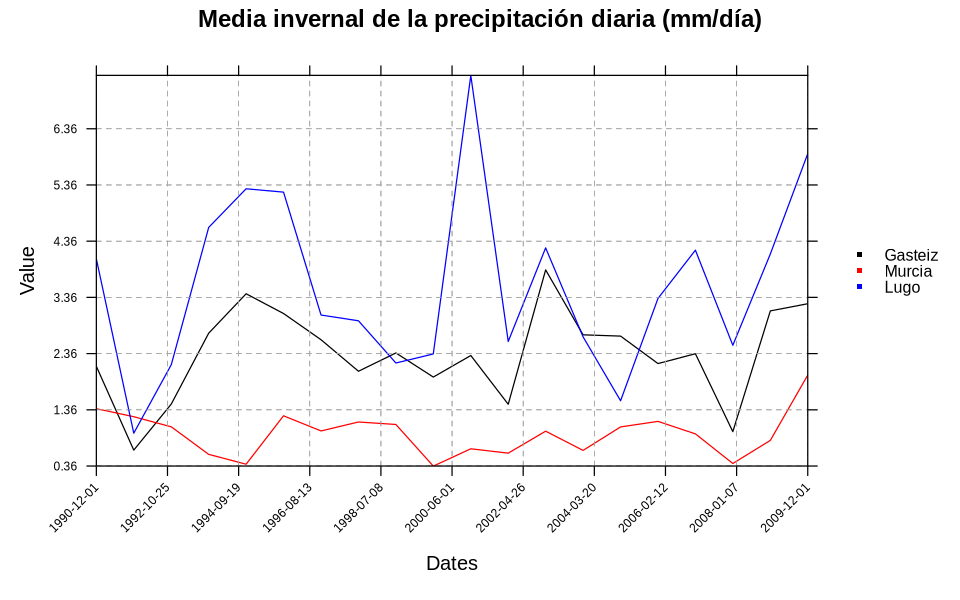

In [16]:
temporalPlot("Gasteiz" = gasteiz, "Murcia" = murcia, "Lugo" = lugo, 
             xyplot.custom = list(main = "Media invernal de la precipitación diaria (mm/día)"))

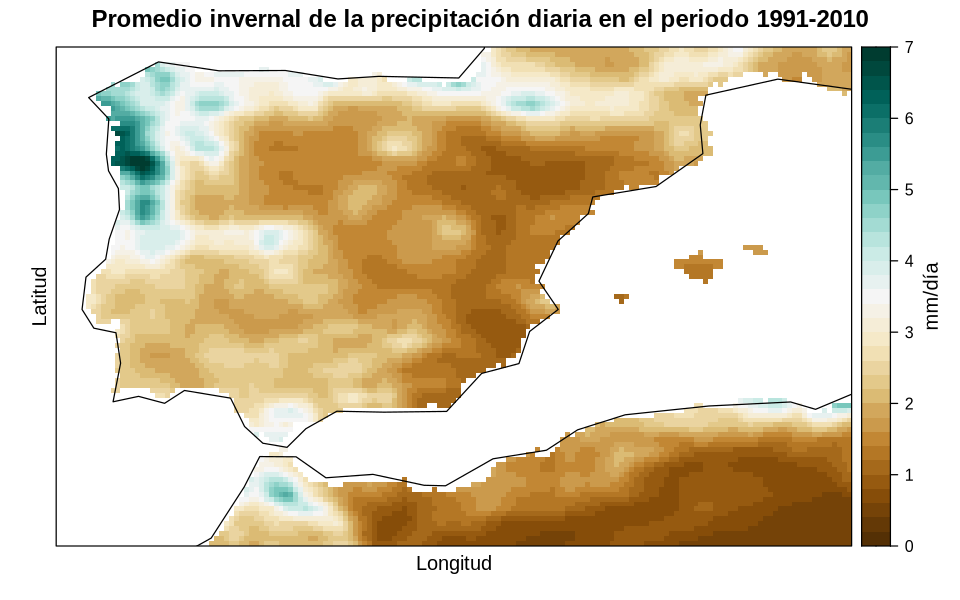

In [17]:
spatialPlot(pr.clim, 
            at = seq(0, 7, 0.2),
            set.max = 7,
            set.min = 0,
            main= "Promedio invernal de la precipitación diaria en el periodo 1991-2010", 
            backdrop.theme = "coastline", 
            color.theme = "BrBG", 
            colorkey = list(space = "right",
                            title = list("mm/día", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
           )

En lugar de la media podemos calcular cualquier otro estadístico con `climatology` definiendo la función de agregación (parámetro `clim.fun`), por ejemplo, podemos visualizar el percentil 90 utilizando previamente la función `quantile` (librería `stats` de R) en el cálculo de la climatología.

In [18]:
pr.clim.p90 <- climatology(pr, clim.fun = list(FUN = "quantile", probs = 0.90, na.rm=TRUE))


[2026-02-11 12:16:54.408744] - Computing climatology...

[2026-02-11 12:16:56.833869] - Done.



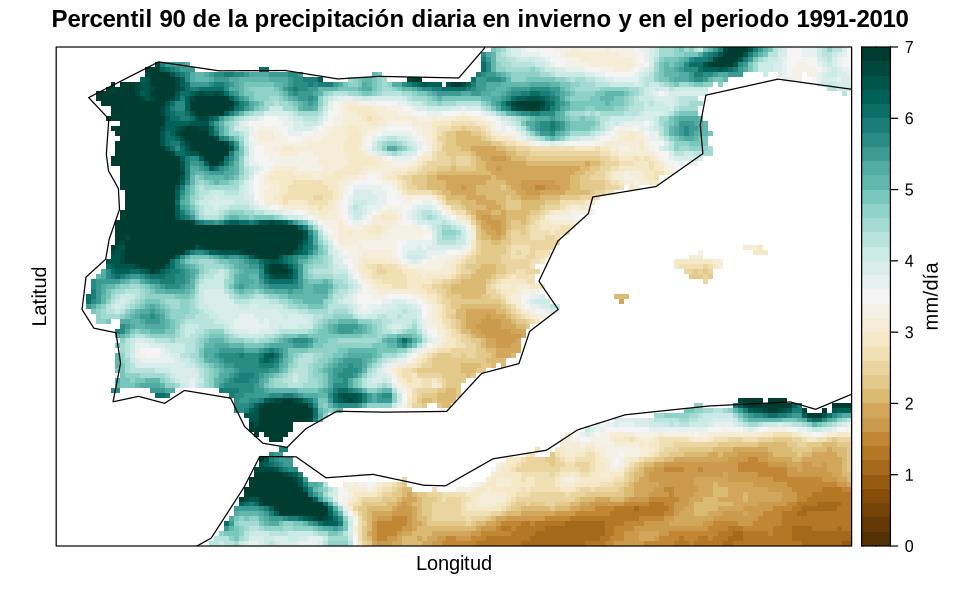

In [19]:
spatialPlot(pr.clim.p90, 
            at = seq(0, 7, 0.2),
            set.max = 7,
            set.min = 0, 
            main = "Percentil 90 de la precipitación diaria en invierno y en el periodo 1991-2010", 
            backdrop.theme = "coastline", 
            color.theme = "BrBG", 
            colorkey = list(space = "right",
                            title = list("mm/día", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
           )

----
A continuación se repite parte del proceso visto anteriormente, considerando el dataset correspondiente a ***Canarias***. En este caso cargaremos la temperatura máxima de verano. Primero cargamos y transformamos los datos.

In [20]:
dataset.can <- subset(df, dataset == "ERA5-Land_Canarias_day")
endpoint.can <- dataset.can$endpoint

tasmax.can <- loadGridData(dataset = endpoint.can,
                           var = "tasmax",
                           season = 6:8,
                           years = 1991:2010,
                           aggr.m = "mean",
                           dictionary = "../../Harmonization_dictionaries/ERA5-Land.dic"
                          )

tasmax.can.clim <- climatology(tasmax.can)
tasmax.can.anual <- aggregateGrid(tasmax.can, aggr.y = list(FUN = "mean", na.rm = T))

[2026-02-11 12:16:57.451028] Defining harmonization parameters for variable "tasmax"

[2026-02-11 12:16:57.474627] Opening dataset...

[2026-02-11 12:16:57.560604] The dataset was successfuly opened

[2026-02-11 12:16:57.56541] Defining geo-location parameters

[2026-02-11 12:16:57.654235] Defining time selection parameters

NOTE: Daily data will be monthly aggregated

[2026-02-11 12:16:57.863883] Retrieving data subset ...

[2026-02-11 12:17:02.379504] Done

[2026-02-11 12:17:02.383425] - Computing climatology...

[2026-02-11 12:17:02.395254] - Done.

[2026-02-11 12:17:02.400867] Performing annual aggregation...

[2026-02-11 12:17:02.612691] Done.



A continuación visualizamos los resultados. En este ejemplo, en lugar de extraer localidades concretas de las islas, representaremos la serie correspondiente a la media regional de todas las islas. La función `temporalPlot` realiza esta aggregación regional de manera automática. 

pad applied on the interval: year



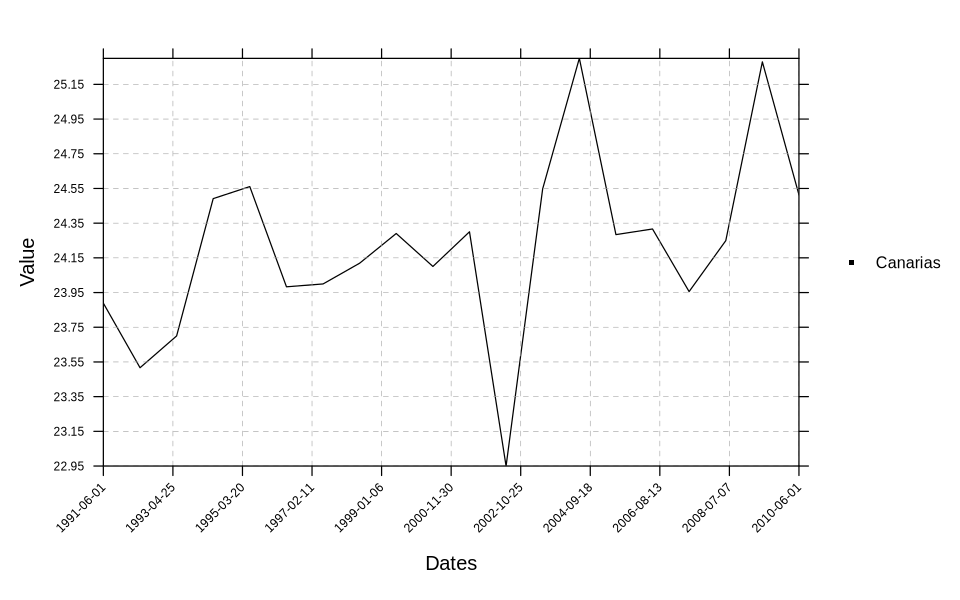

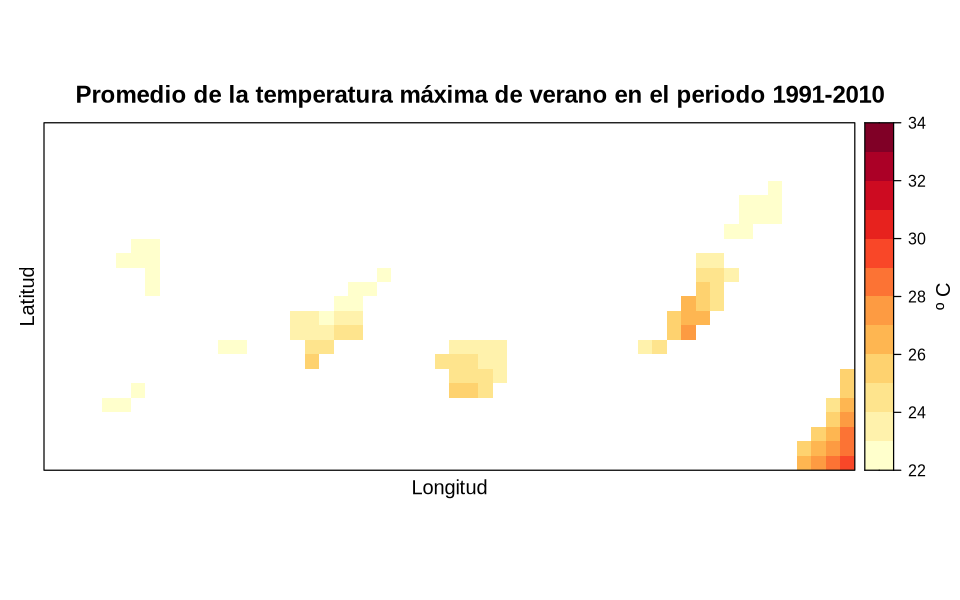

In [21]:
temporalPlot("Canarias" = tasmax.can.anual)

spatialPlot(tasmax.can.clim, 
            at = seq(22, 34, 1),
            set.max = 34,
            set.min = 22,
            main= "Promedio de la temperatura máxima de verano en el periodo 1991-2010", 
            color.theme = "YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
           )

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

La Plataforma Virtual de Cálculo ofrece un **notebook de primeros pasos** y una **colección de notebooks temáticos** (p. ej., intercomparación de conjuntos de datos observacionales o cálculo de índices) que puedes consultar para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.

***

### Session Info

In [22]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] visualizeR_1.6.4    transformeR_2.2.2   loadeR_1.8.1       
[4] climate4R.UDG_0.2.6 loadeR.java_1.1.1   rJava_1.0-11       
[7] repr_1.1.7         

loaded via a namespace (and not attached):
 [1] dot